In [38]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd

pb_atac_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/agg_atac_ct.h5ad")
pb_atac_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/agg_atac_ct_time.h5ad")

First checking whether the peaks are aligned to the numbered chromosome, so there aren't any unknown scaffolds and filtering the ones not aligned to the numbered chromosomes out

In [39]:
#extract the first two characters of all the values of peaks index and get unique values among those and sort them
unique_peak_prefixes = sorted(set(peak[:2] for peak in pb_atac_ct.var_names))
print(f"Unique peak prefixes (ct): {unique_peak_prefixes}")

unique_peak_prefixes_time = sorted(set(peak[:2] for peak in pb_atac_ct_time.var_names))
print(f"Unique peak prefixes (ct_time): {unique_peak_prefixes_time}")

#now remove all peaks that start with "MT" 
pb_atac_ct = pb_atac_ct[:, ~pb_atac_ct.var_names.str.startswith("MT")]
pb_atac_ct_time = pb_atac_ct_time[:, ~pb_atac_ct_time.var_names.str.startswith("MT")]   

unique_peak_prefixes = sorted(set(peak[:2] for peak in pb_atac_ct.var_names))
print(f"Unique peak prefixes (ct): {unique_peak_prefixes}")

unique_peak_prefixes_time = sorted(set(peak[:2] for peak in pb_atac_ct_time.var_names))
print(f"Unique peak prefixes (ct_time): {unique_peak_prefixes_time}")

Unique peak prefixes (ct): ['1-', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2-', '20', '21', '22', '23', '24', '25', '3-', '4-', '5-', '6-', '7-', '8-', '9-', 'MT']
Unique peak prefixes (ct_time): ['1-', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2-', '20', '21', '22', '23', '24', '25', '3-', '4-', '5-', '6-', '7-', '8-', '9-', 'MT']
Unique peak prefixes (ct): ['1-', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2-', '20', '21', '22', '23', '24', '25', '3-', '4-', '5-', '6-', '7-', '8-', '9-']
Unique peak prefixes (ct_time): ['1-', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2-', '20', '21', '22', '23', '24', '25', '3-', '4-', '5-', '6-', '7-', '8-', '9-']


In [48]:
# obs = rows = cell types, vars = cols = peaks
print(len(pb_atac_ct.obs_names))
print(len(pb_atac_ct.var_names))

#sesarching for any var_names with the pattern "MT-"
mt_ct_peaks = [peak for peak in pb_atac_ct.var_names if "MT" in peak]
print(f"Number of peaks with 'MT-' in their name: {len(mt_peaks)}") 

mt_ct_time_peaks = [peak for peak in pb_atac_ct.var_names if "MT" in peak]
print(f"Number of peaks with 'MT-' in their name: {len(mt_ct_time_peaks)}") 


39
640832
Number of peaks with 'MT-' in their name: 2
Number of peaks with 'MT-' in their name: 0


In [46]:
#Save the var_names of the filtered pb_atac_ct and pb_atac_ct_time as a csv file
pb_atac_ct.var_names.to_series().to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/filtered_peaks_ct.csv", index=False)
pb_atac_ct_time.var_names.to_series().to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/filtered_peaks_ct_time.csv", index=False)

## Plotting the distribution of the value of the peaks across all cell types (+ developmental stages) in a boxplot

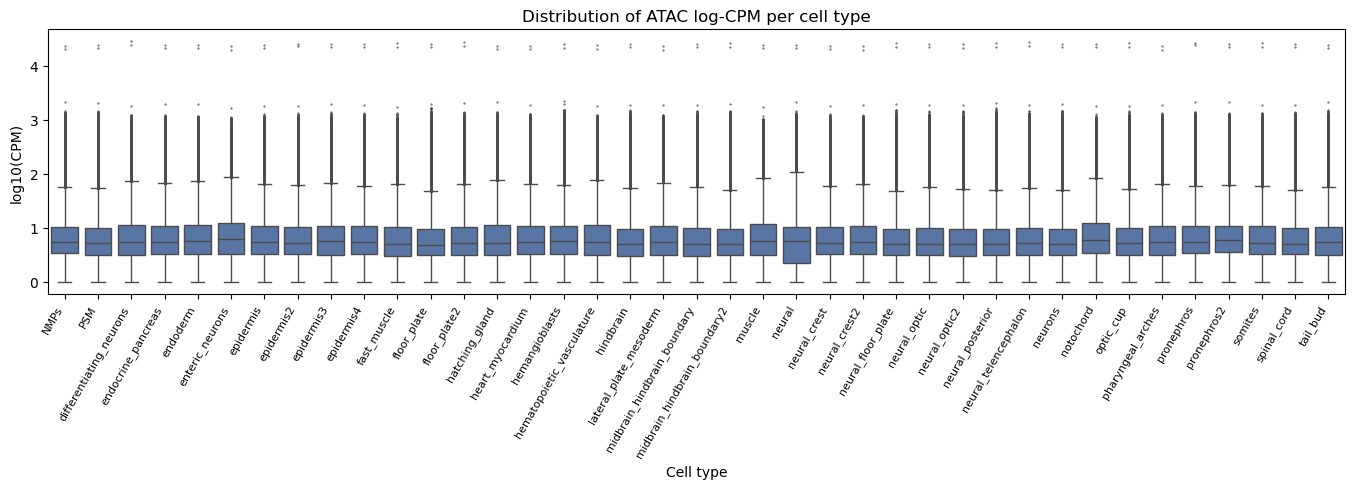

In [2]:
#Plotting the distribution of the value of the peaks across all cell types in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# peaks × samples
P = pb_atac_ct.X.T.astype(float)

#log transformation (for norm. distribution) & scaling 10000000+1
P_scaled = np.log10(P * 10000000+1)  # log10 to handle zeros and scaling for better visualization

# convert to long format for seaborn
P_scaled_plot = pd.DataFrame(P_scaled, columns=pb_atac_ct.obs_names).melt(
	var_name="celltype",
	value_name="log_cpm"
)

plt.figure(figsize=(max(10, len(pb_atac_ct.obs_names) * 0.35), 5))
sns.boxplot(data=P_scaled_plot, x="celltype", y="log_cpm", color="#4C72B0", fliersize=0.5)
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.xlabel("Cell type")
plt.ylabel("log10(CPM)")
plt.title("Distribution of ATAC log-CPM per cell type")
plt.tight_layout()
plt.show()


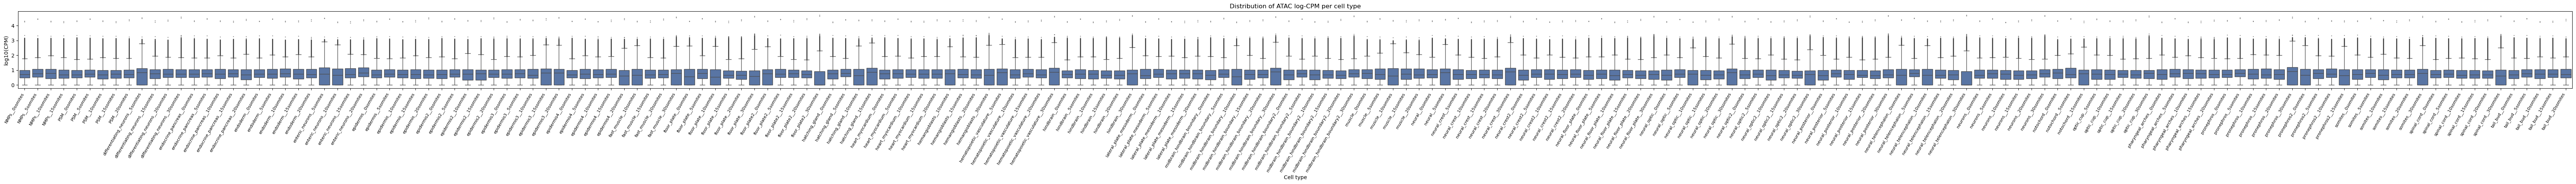

In [8]:
#Plotting the distribution of the value of the peaks across all cell types + times in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# peaks × samples
P = pb_atac_ct_time.X.T.astype(float)

#log transformation (for norm. distribution) & scaling 10000000+1
P_scaled = np.log10(P * 10000000+1)  # log10 to handle zeros and scaling for better visualization

# convert to long format for seaborn
P_scaled_plot = pd.DataFrame(P_scaled, columns=pb_atac_ct_time.obs_names).melt(
	var_name="celltype",
	value_name="log_cpm"
)

plt.figure(figsize=(max(10, len(pb_atac_ct_time.obs_names) * 0.35), 5))
sns.boxplot(data=P_scaled_plot, x="celltype", y="log_cpm", color="#4C72B0", fliersize=0.5)
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.xlabel("Cell type per developmental stage")
plt.ylabel("log10(CPM)")
plt.title("Distribution of ATAC log-CPM per cell type and developmental stage")
plt.tight_layout()
plt.show()


## Counting total counts per cell type (sum across all peaks)
- needed to explain the normalization step in the boxplot distribution 

/tmp/ipykernel_2805355/2556259190.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=peaks_per_celltype, x="celltype", y="n_peaks", palette=bar_colors, order=peaks_per_celltype["celltype"].values)


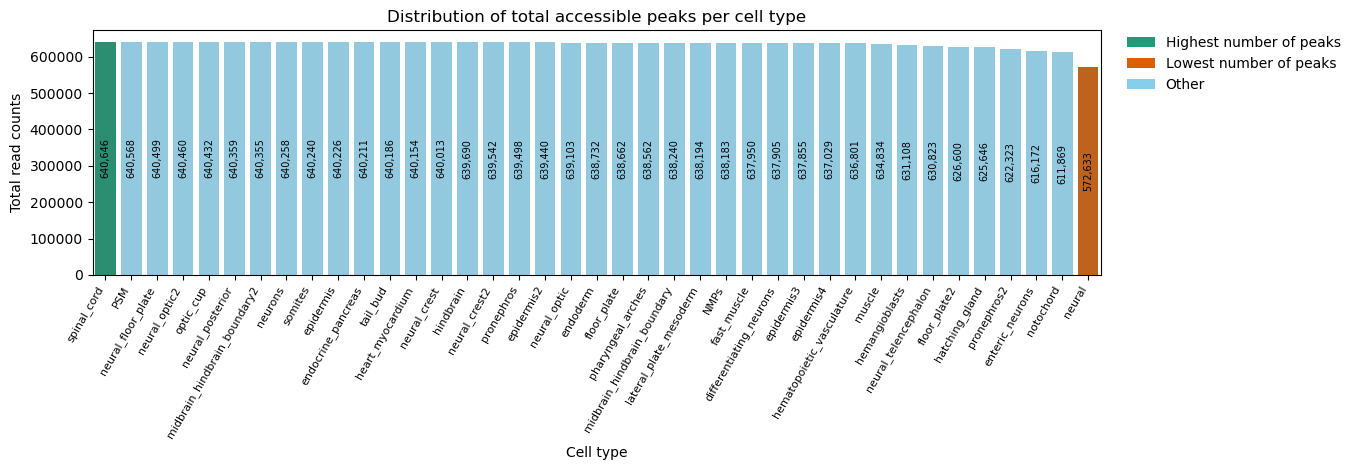

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from matplotlib.patches import Patch

# Total ATAC read counts per cell type (sum across all peaks) - needed to explain the normalization step in the boxplot distribution 
P_counts = pb_atac_ct.X # rows = cell types, cols = peaks  
P_total_counts_per_celltype = (P_counts>0).sum(axis=1) 
celltype_labels = pb_atac_ct.obs_names.astype(str)

# Group by cell type and sum accessible peaks
summary_df = pd.DataFrame({
    "celltype": pb_atac_ct.obs["annotation_ML"].astype(str).values,
    "n_peaks": P_total_counts_per_celltype,
})
peaks_per_celltype = summary_df.groupby("celltype", as_index=False)["n_peaks"].sum()
peaks_per_celltype = peaks_per_celltype.sort_values("n_peaks", ascending=False)
#print(peaks_per_celltype)


# Color lowest and highest values based on sorted data
sorted_values = peaks_per_celltype["n_peaks"].values
p_min_idx = int(np.argmin(sorted_values))
p_max_idx = int(np.argmax(sorted_values))
bar_colors = ["skyblue"] * len(sorted_values)
bar_colors[p_min_idx] = "#D95F02"  # lowest
bar_colors[p_max_idx] = "#1B9E77"  # highest

# Plotting the total read counts per cell type (bars in descending order)
plt.figure(figsize=(max(10, len(peaks_per_celltype) * 0.35), 4.8))
ax = sns.barplot(data=peaks_per_celltype, x="celltype", y="n_peaks", palette=bar_colors, order=peaks_per_celltype["celltype"].values)

ax.set_xlabel("Cell type")
ax.set_ylabel("Total read counts")
ax.set_title("Distribution of total accessible peaks per cell type")
plt.xticks(rotation=60, ha="right", fontsize=8)

# Add y-values on bars
for bar, v in zip(ax.patches, sorted_values):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        x, y, f"{v:,.0f}",
        ha="center", va="center",
        rotation=90, fontsize=7, color="black"
    )

legend_handles = [
    Patch(facecolor="#1B9E77", label="Highest number of peaks"),
    Patch(facecolor="#D95F02", label="Lowest number of peaks"),
    Patch(facecolor="skyblue", label="Other"),
]
ax.legend(
    handles=legend_handles,
    loc="upper left",           # anchor point on the legend box
    bbox_to_anchor=(1.02, 1.0), # just right of the axes
    frameon=False,
    borderaxespad=0.0
)
plt.subplots_adjust(right=0.82)  # make room for outside legend

plt.tight_layout()
plt.show()

/tmp/ipykernel_2805355/1955585344.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=peaks_per_ct_time, y="celltype", x="n_peaks", palette=bar_colors, orient="h", order=peaks_per_ct_time["celltype"].values)


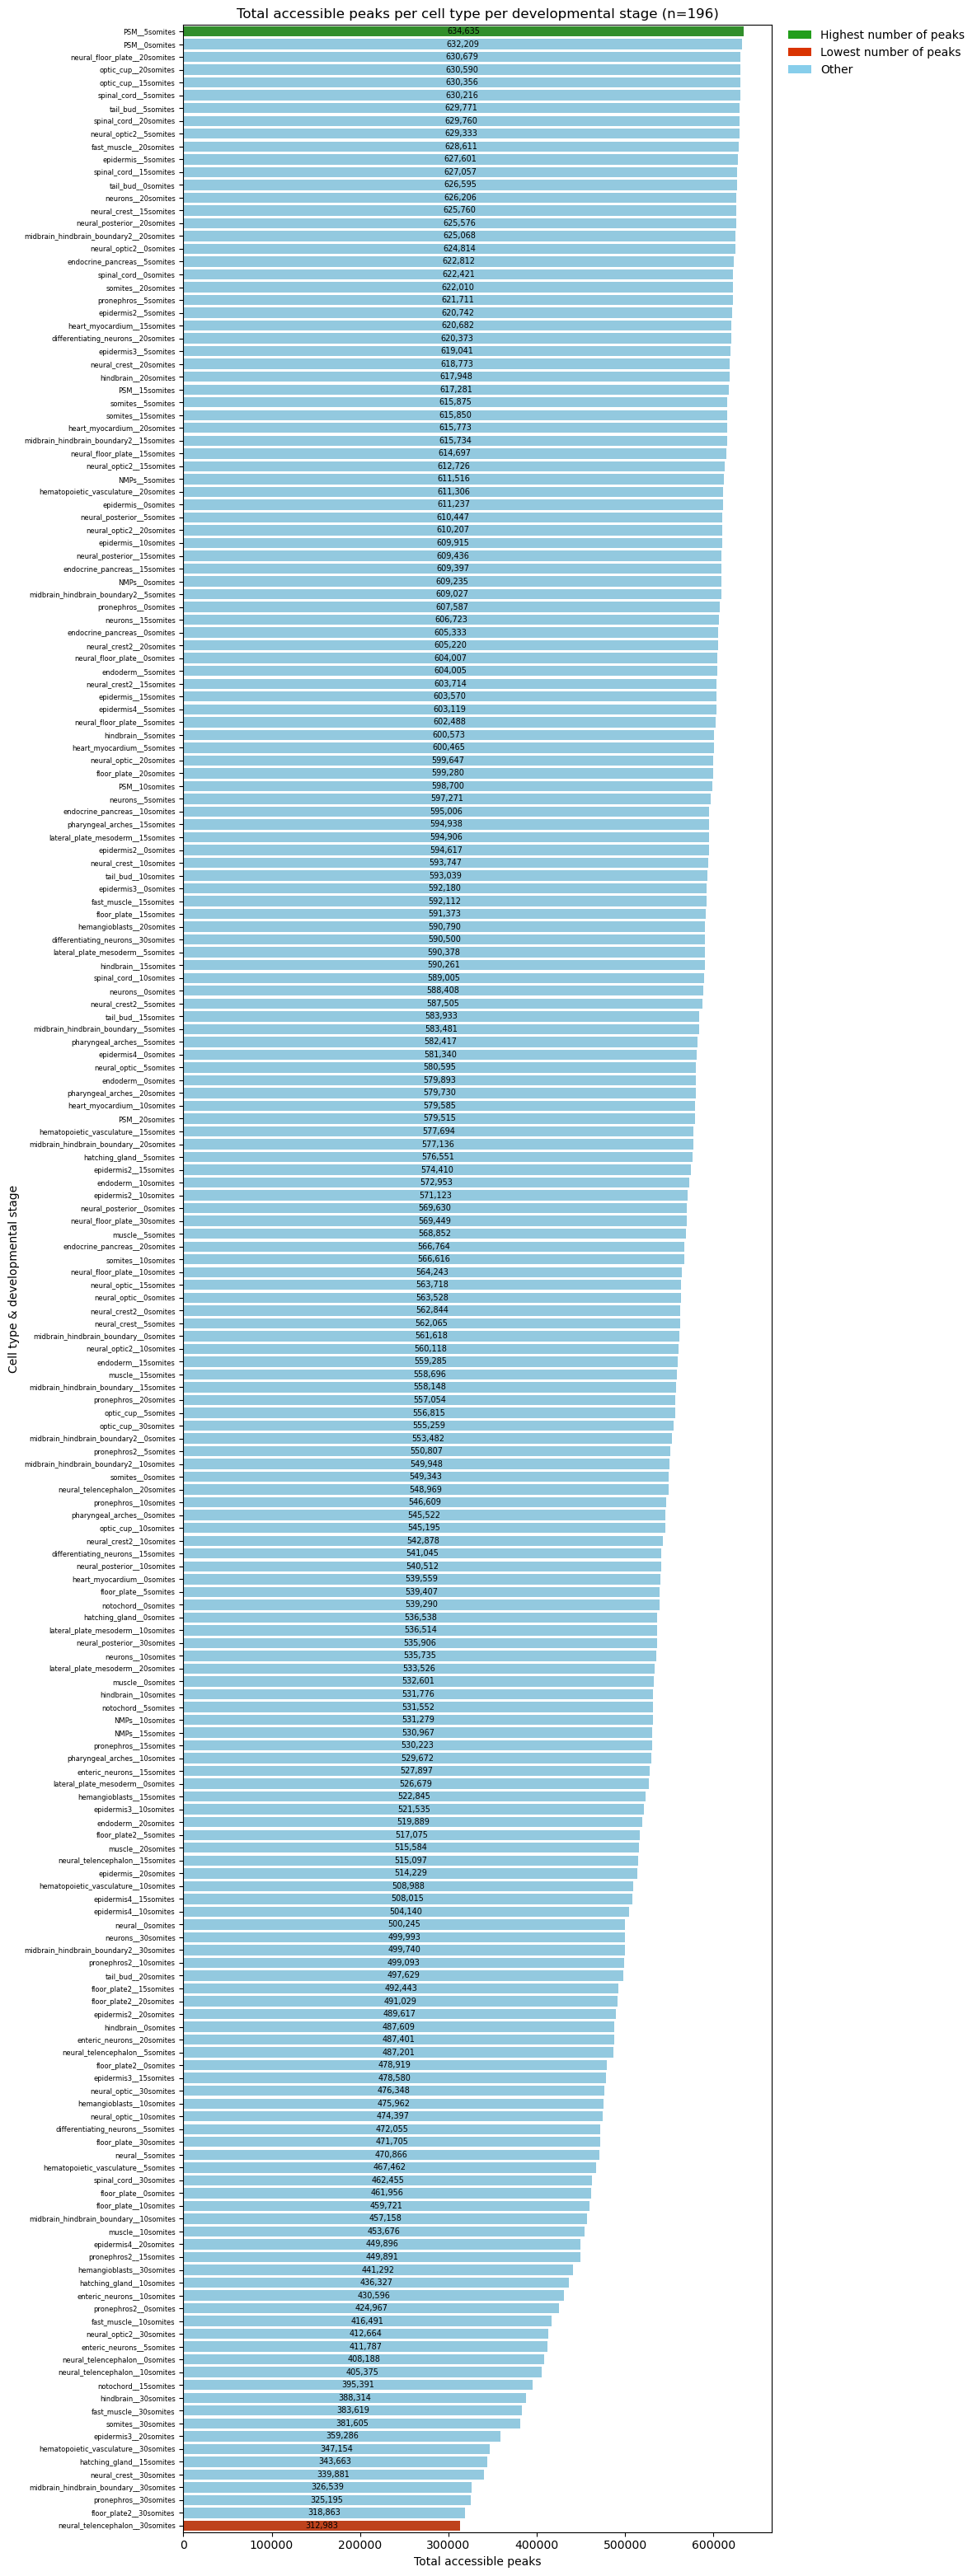

,celltype,n_peaks
0,PSM__5somites,634635
1,PSM__0somites,632209
2,neural_floor_plate__20somites,630679
3,optic_cup__20somites,630590
4,optic_cup__15somites,630356


In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from matplotlib.patches import Patch

# Total ATAC accessibility counts per celltype+stage (sum across all peaks)
P_counts = pb_atac_ct_time.X # rows = cell types & dev. stages, cols = peaks  
P_total_counts_per_ct_time = (P_counts>0).sum(axis=1) 
celltype_labels = pb_atac_ct_time.obs_names.astype(str) 

# Group by annotation and sum
summary_df = pd.DataFrame({
    "celltype": pb_atac_ct_time.obs_names.astype(str).values,
    "n_peaks": P_total_counts_per_ct_time,
})
peaks_per_ct_time = (
    summary_df.groupby("celltype", as_index=False)["n_peaks"]
    .sum()
    .sort_values("n_peaks", ascending=False)
    .reset_index(drop=True)
)

# Build colors from grouped values (sorted order)
sorted_values = peaks_per_ct_time["n_peaks"].values
p_min_idx = int(np.argmin(sorted_values))
p_max_idx = int(np.argmax(sorted_values))
bar_colors = ["skyblue"] * len(sorted_values)
bar_colors[p_min_idx] = "#D93402"  # lowest
bar_colors[p_max_idx] = "#229E1B"  # highest

# For 196 categories, horizontal bars are much more readable
fig_h = max(8, len(peaks_per_ct_time) * 0.16)
plt.figure(figsize=(12, fig_h))
ax = sns.barplot(data=peaks_per_ct_time, y="celltype", x="n_peaks", palette=bar_colors, orient="h", order=peaks_per_ct_time["celltype"].values)

ax.set_ylabel("Cell type & developmental stage")
ax.set_xlabel("Total accessible peaks")
ax.set_title(f"Total accessible peaks per cell type per developmental stage (n={len(peaks_per_ct_time)})")
ax.tick_params(axis="y", labelsize=6)

#Add y-values on bars
for bar, v in zip(ax.patches, sorted_values):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        x, y, f"{v:,.0f}",
        ha="center", va="center",
        rotation=0, fontsize=7, color="black"
    )

legend_handles = [
    Patch(facecolor="#229E1B", label="Highest number of peaks"),
    Patch(facecolor="#D93402", label="Lowest number of peaks"),
    Patch(facecolor="skyblue", label="Other"),
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()

peaks_per_ct_time.head()

In [50]:
#checking if there are any peaks with almost zero accessibility across all samples
P = pb_atac_ct.X.T

zero_accessibility_peaks = np.sum(P, axis=1) == 1e-10  # Using a small threshold to account for floating-point precision
print(f"Number of peaks with zero accessibility across all samples: {np.sum(zero_accessibility_peaks)}")

min_accessibility_peaks = np.sum(P, axis=1) < 1e-10
min_accessibility_peaks


Number of peaks with zero accessibility across all samples: 0


array([False, False, False, ..., False, False, False], shape=(640834,))

## Visualization of the pb ATAC-Seq data
- computing & plotting the statistics
    - log(max/ mean/median)

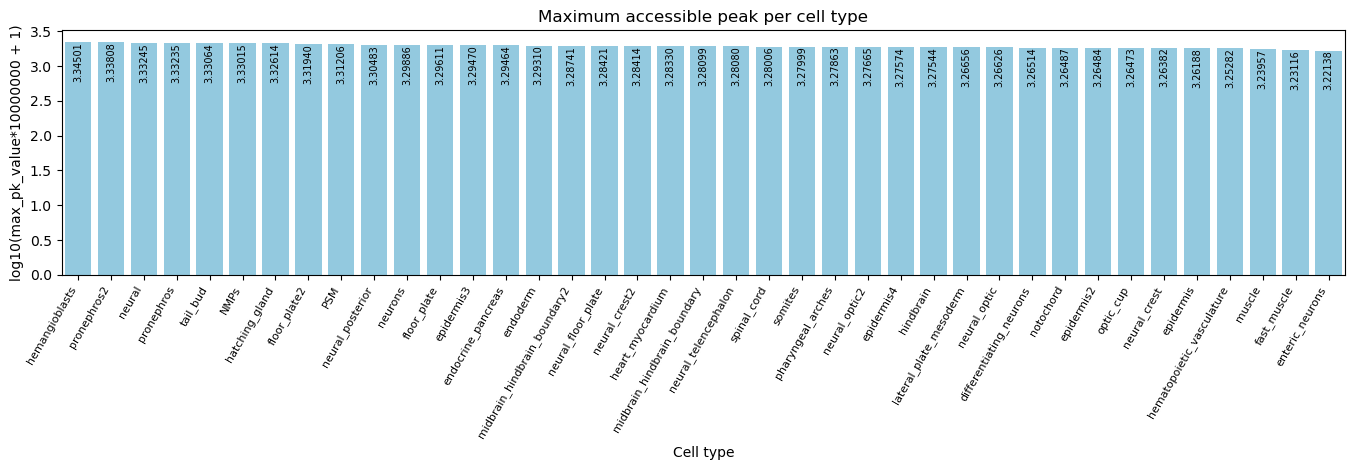

Min maximal accessible peak value: 3.22138, enteric_neurons
Max maximal accessible peak value: 3.34501, hemangioblasts


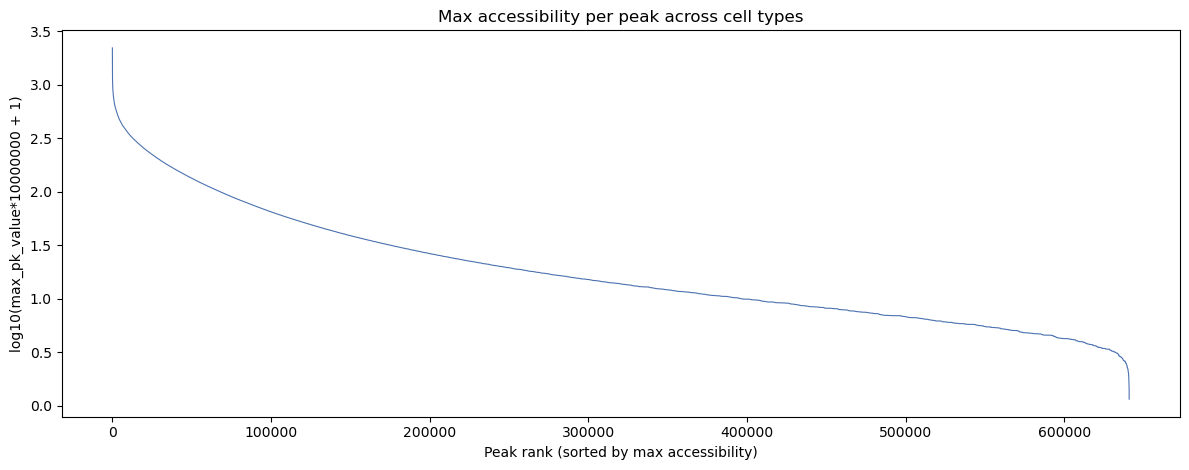

                   peak  max_accessible_peak
0        10-73855-77448             3.345007
1  17-53383392-53383848             3.294161
2   7-19551215-19554074             3.226367
3   8-29973242-29975835             3.216846
4   7-21721058-21724007             3.206438
5   6-19815211-19818397             3.201476
6   2-56482187-56482577             3.198073
7  14-31564921-31567544             3.187756
8    20-2948323-2951321             3.180690
9     3-7653871-7656871             3.179501


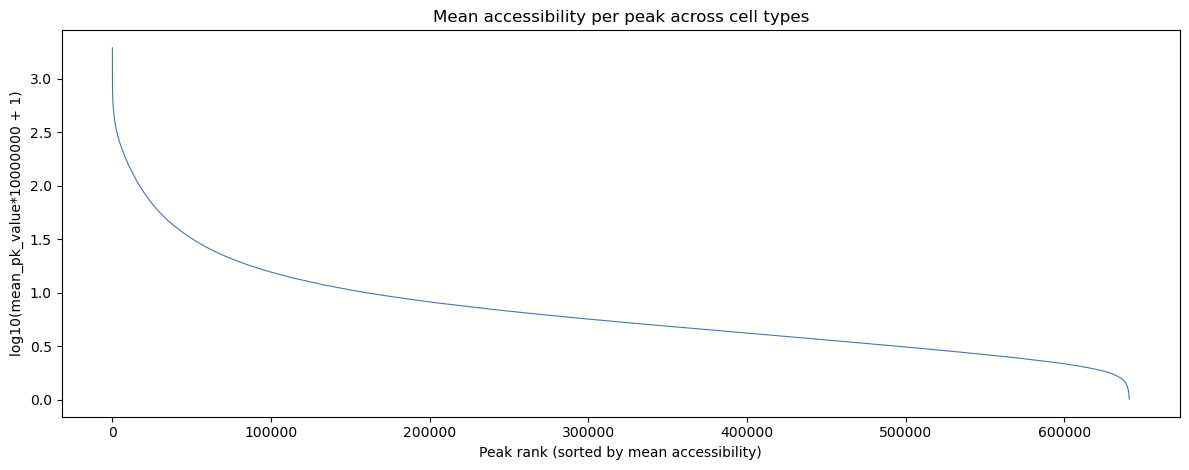

                   peak  mean_accessible_peak
0        10-73855-77448              3.286639
1  17-53383392-53383848              3.113291
2  14-31564921-31567544              3.107099
3   8-26866637-26869361              3.095961
4     2-5132806-5136303              3.093805
5   7-33683082-33686500              3.090943
6   7-21721058-21724007              3.086777
7    20-2948323-2951321              3.083164
8   6-29789748-29793538              3.081556
9   5-13644712-13647625              3.067782


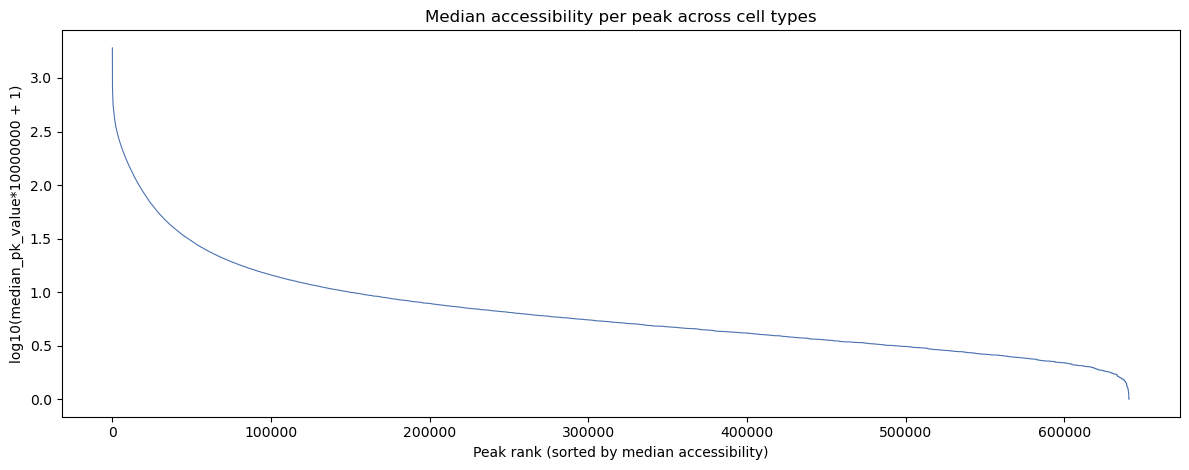

                   peak  median_accessible_peak
0        10-73855-77448                3.280985
1  17-53383392-53383848                3.117379
2  14-31564921-31567544                3.108167
3   8-26866637-26869361                3.097299
4   7-33683082-33686500                3.092864
5     2-5132806-5136303                3.092256
6   7-21721058-21724007                3.087809
7   6-29789748-29793538                3.083022
8   2-56482187-56482577                3.077453
9    20-2948323-2951321                3.072970


In [40]:
## Distribution of statistical value of accessible peaks per cell type 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

# pb_atac_ct.X: rows = cell types, cols = peaks
P = pb_atac_ct.X

# Log-transform and compute max accessible peak value per row/category (ct)
P_scaled = np.log10(P * 10000000 + 1)
max_peak_values = P_scaled.max(axis=1)

max_ct_df = pd.DataFrame({
    "celltype_time": pb_atac_ct.obs_names.astype(str),
    "max_accessible_peak": max_peak_values,
}).sort_values("max_accessible_peak", ascending=False)

plt.figure(figsize=(max(10, len(max_ct_df) * 0.35), 4.8))
ax = sns.barplot(data=max_ct_df, x="celltype_time", y="max_accessible_peak", color="skyblue")

ax.set_xlabel("Cell type")
ax.set_ylabel("log10(max_pk_value*10000000 + 1)")
ax.set_title("Maximum accessible peak per cell type")
plt.xticks(rotation=60, ha="right", fontsize=8)

# Label bars with the max value
for bar, v in zip(ax.patches, max_ct_df["max_accessible_peak"]):
    h = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    ax.text(
        x, h, f"{v:.5f}",
        ha="center", va="top",
        rotation=90,
        fontsize=7, color="black"
    )
plt.tight_layout()
plt.show()

#print the min and max value of maximal accessible peaks with the category 
min_idx = max_ct_df["max_accessible_peak"].idxmin()
max_idx = max_ct_df["max_accessible_peak"].idxmax()

print(
    f"Min maximal accessible peak value: {max_ct_df.loc[min_idx, 'max_accessible_peak']:.5f}, "
    f"{max_ct_df.loc[min_idx, 'celltype_time']}"
)
print(
    f"Max maximal accessible peak value: {max_ct_df.loc[max_idx, 'max_accessible_peak']:.5f}, "
    f"{max_ct_df.loc[max_idx, 'celltype_time']}"
)

# Calculate max values among the peaks across the cell types
# Sparse-safe log10 transform: only non-zero entries need transformation 
# pb_atac_ct.X: rows = cell types, cols = peaks
P = pb_atac_ct.X
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    max_peak_values = np.asarray(P_log.max(axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    max_peak_values = P_log.max(axis=0) # max across cell types for each peak

peak_max_ct_df = pd.DataFrame({
    "peak": pb_atac_ct.var_names.astype(str),
    "max_accessible_peak": max_peak_values,
}).sort_values("max_accessible_peak", ascending=False).reset_index(drop=True)

# Plot each peak max (ranked) across cell types
plt.figure(figsize=(12, 4.8))
plt.plot(
    peak_max_ct_df.index,
    peak_max_ct_df["max_accessible_peak"],
    color="#4C72B0",
    linewidth=0.8,
)
plt.xlabel("Peak rank (sorted by max accessibility)")
plt.ylabel("log10(max_pk_value*10000000 + 1)")
plt.title("Max accessibility per peak across cell types")
plt.tight_layout()
plt.show()

# Show the highest-max peaks
print(peak_max_ct_df.head(10))


# Calculate mean values among the peaks across the cell types
# Sparse-safe log10 transform: only non-zero entries need transformation.
# pb_atac_ct.X: rows = cell types, cols = peaks
P = pb_atac_ct.X
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    mean_peak_values = np.asarray(P_log.mean(axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    mean_peak_values = P_log.mean(axis=0) # mean across cell types for each peak

peak_mean_ct_df = pd.DataFrame({
    "peak": pb_atac_ct.var_names.astype(str),
    "mean_accessible_peak": mean_peak_values,
}).sort_values("mean_accessible_peak", ascending=False).reset_index(drop=True)

# Plot each peak mean (ranked) across cell types
plt.figure(figsize=(12, 4.8))
plt.plot(
    peak_mean_ct_df.index,
    peak_mean_ct_df["mean_accessible_peak"],
    color="#4C72B0",
    linewidth=0.8,
)
plt.xlabel("Peak rank (sorted by mean accessibility)")
plt.ylabel("log10(mean_pk_value*10000000 + 1)")
plt.title("Mean accessibility per peak across cell types")
plt.tight_layout()
plt.show()

# Show the highest-mean peaks
print(peak_mean_ct_df.head(10))


# Calculate median values among the peaks across the cell types
# Sparse-safe log10 transform: only non-zero entries need transformation.
# pb_atac_ct.X: rows = cell types, cols = peaks
P = pb_atac_ct.X
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    median_peak_values = np.asarray(np.median(P_log, axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    median_peak_values = np.median(P_log, axis=0) # median across cell types for each peak

peak_median_ct_df = pd.DataFrame({
    "peak": pb_atac_ct.var_names.astype(str),
    "median_accessible_peak": median_peak_values,
}).sort_values("median_accessible_peak", ascending=False).reset_index(drop=True)

# Plot each peak median (ranked) across cell types
plt.figure(figsize=(12, 4.8))
plt.plot(
    peak_median_ct_df.index,
    peak_median_ct_df["median_accessible_peak"],
    color="#4C72B0",
    linewidth=0.8,
)
plt.xlabel("Peak rank (sorted by median accessibility)")
plt.ylabel("log10(median_pk_value*10000000 + 1)")
plt.title("Median accessibility per peak across cell types")
plt.tight_layout()
plt.show()

# Show the highest-median peaks
print(peak_median_ct_df.head(10))



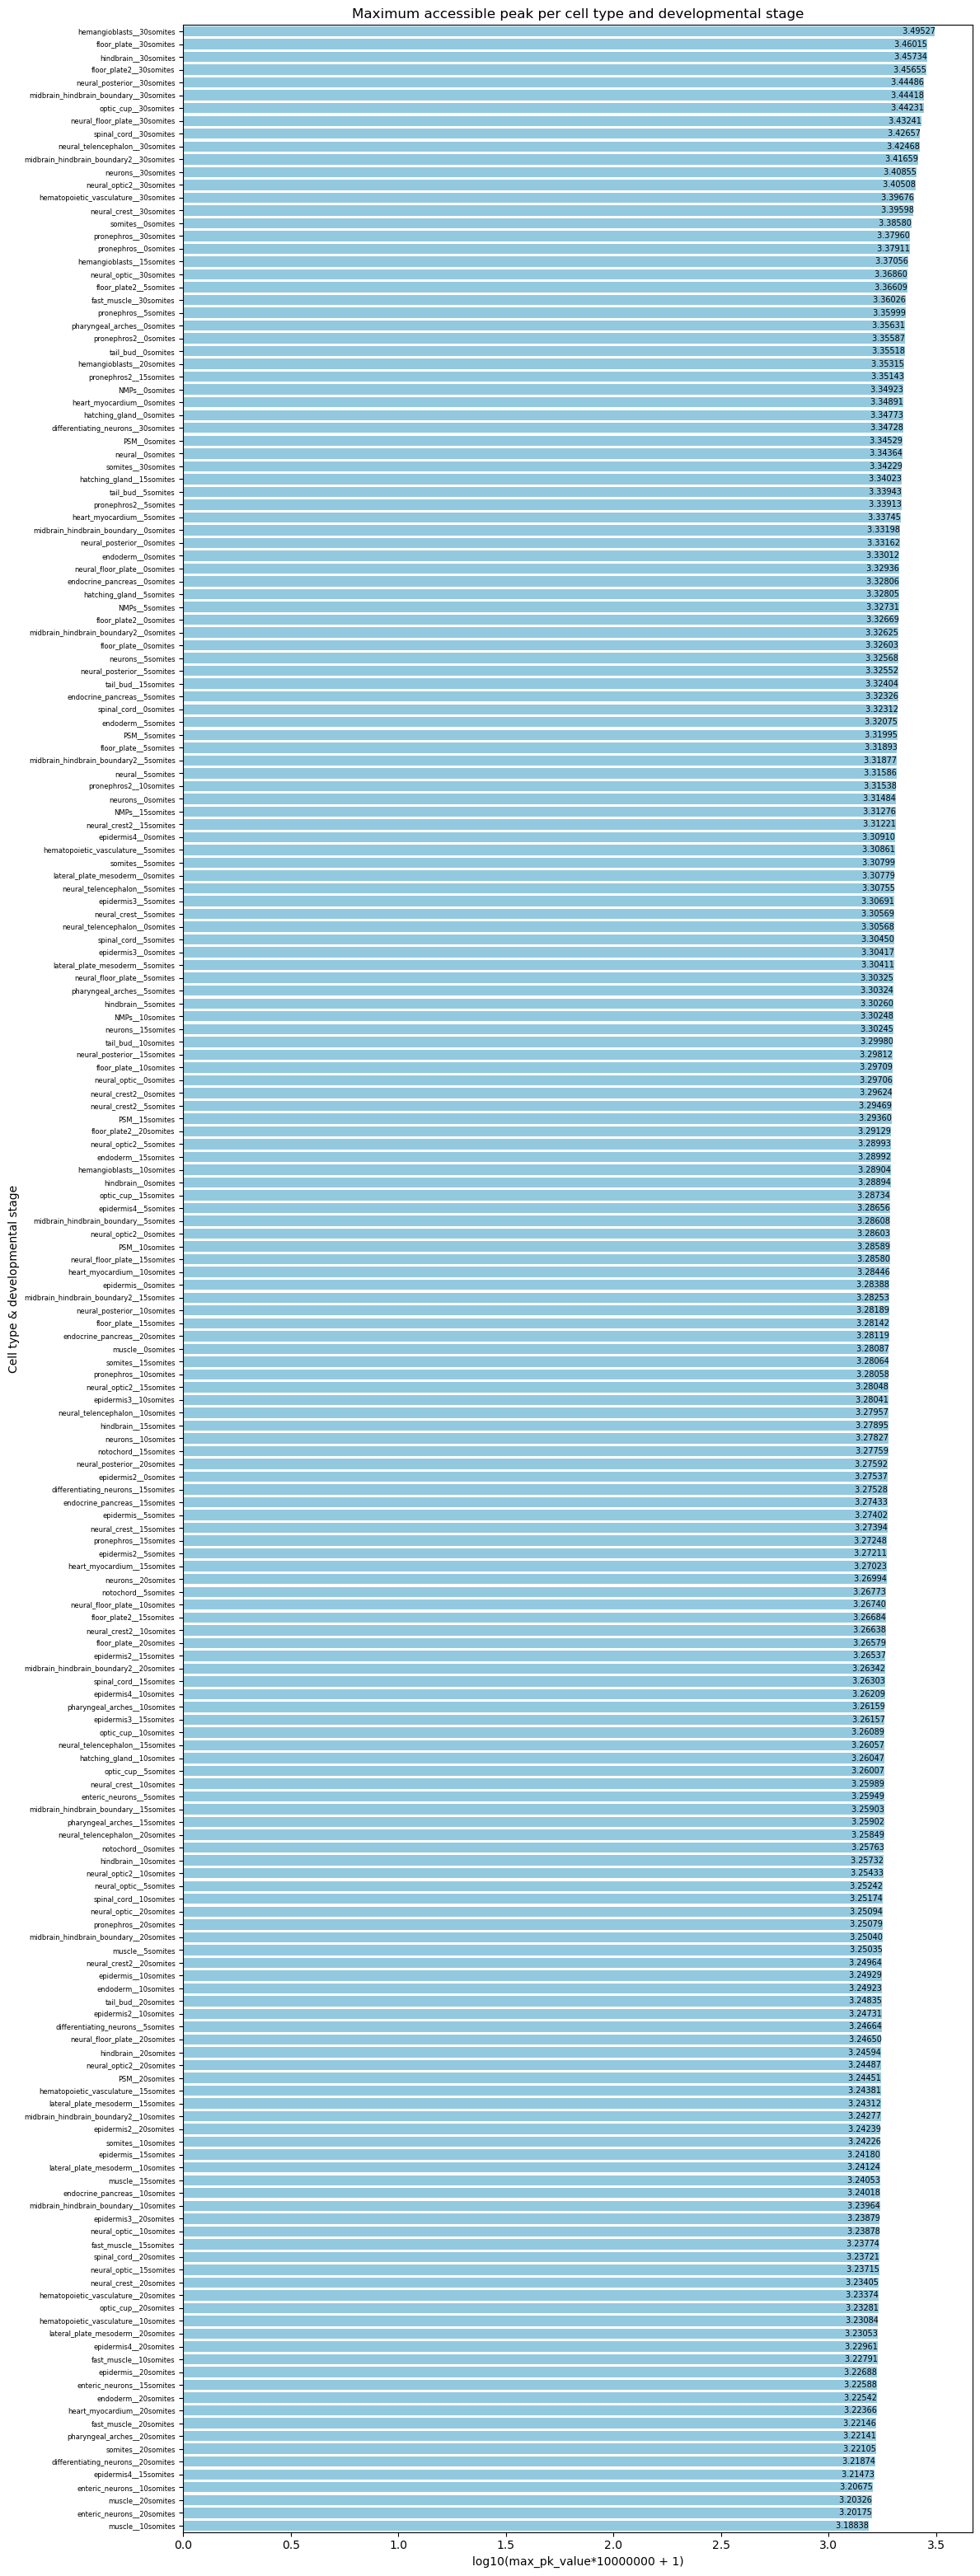

Min maximal accessible peak value: 3.18838, muscle__10somites
Max maximal accessible peak value: 3.49527, hemangioblasts__30somites


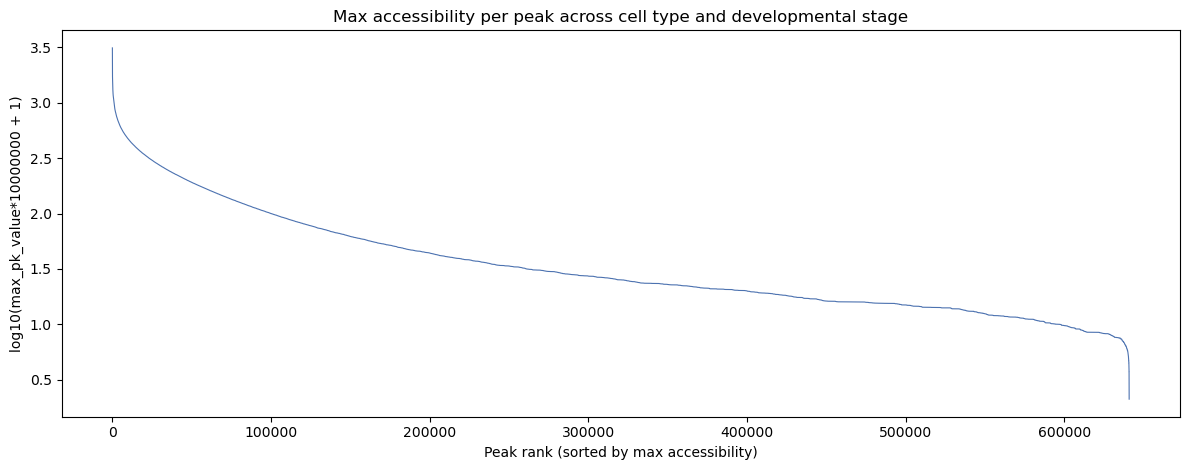

                   peak  max_accessible_peak
0        10-73855-77448             3.495265
1   5-36612612-36616248             3.460145
2  17-53383392-53383848             3.457339
3   8-29973242-29975835             3.444387
4   2-56482187-56482577             3.407213
5   7-19551215-19554074             3.393363
6  14-31564921-31567544             3.388961
7   2-31714880-31715675             3.370562
8   3-20061325-20064395             3.367168
9  17-41883401-41885348             3.353083


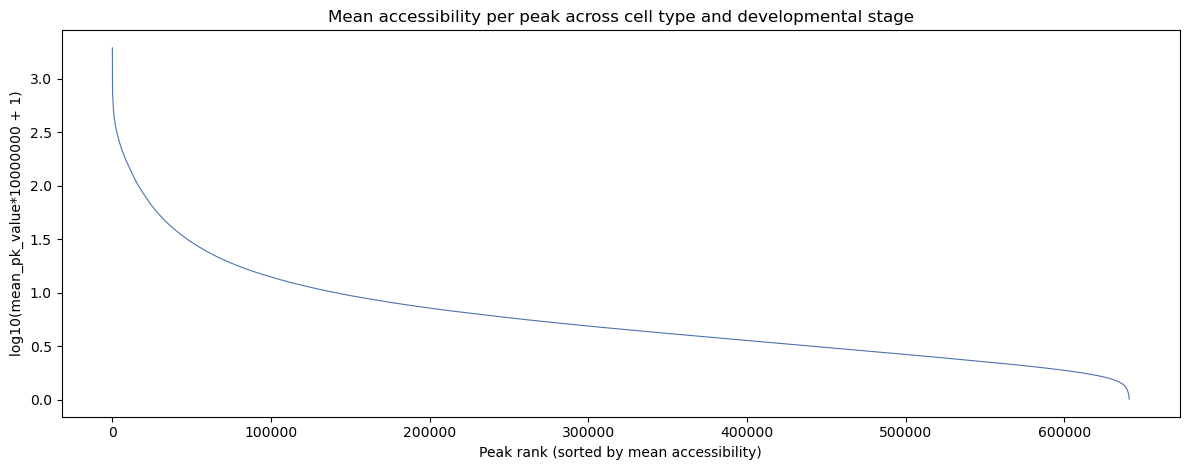

                   peak  mean_accessible_peak
0        10-73855-77448              3.288974
1  17-53383392-53383848              3.128297
2  14-31564921-31567544              3.117086
3   7-33683082-33686500              3.102016
4   8-26866637-26869361              3.101032
5     2-5132806-5136303              3.099865
6   7-21721058-21724007              3.096718
7   6-29789748-29793538              3.089876
8    20-2948323-2951321              3.087441
9   2-56482187-56482577              3.076293


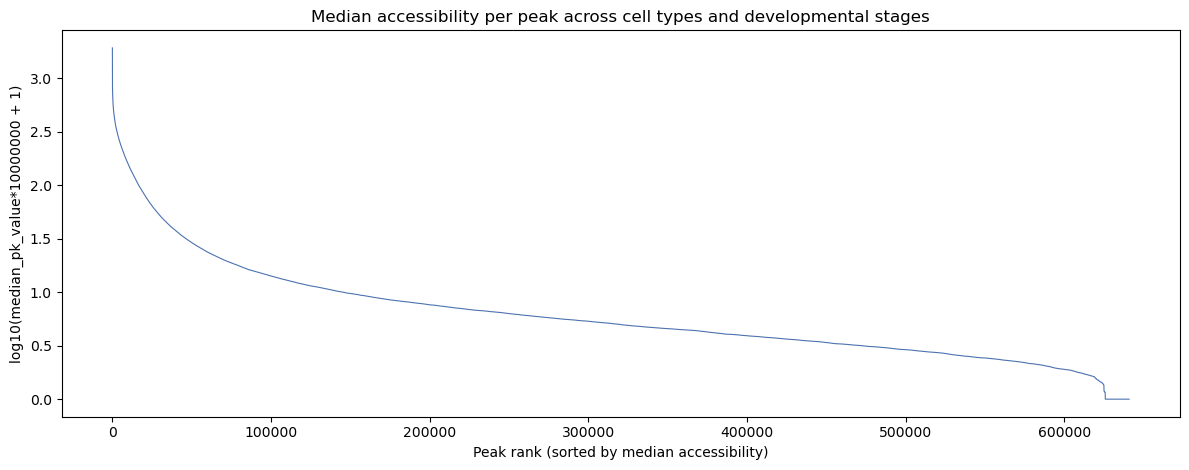

                   peak  median_accessible_peak
0        10-73855-77448                3.283203
1  17-53383392-53383848                3.118441
2  14-31564921-31567544                3.111802
3   7-21721058-21724007                3.101760
4   7-33683082-33686500                3.099056
5   8-26866637-26869361                3.095400
6     2-5132806-5136303                3.092789
7   6-29789748-29793538                3.085633
8    20-2948323-2951321                3.075796
9         4-19583-21435                3.071791


In [41]:
## Distribution of statistical value of accessible peaks per cell type and developmental stage
## Maximum value of accessible peaks per cell type and developmental stage 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# pb_atac_ct_time.X: rows = cell types + developmental stages, cols = peaks
P = pb_atac_ct_time.X

# Log-transform and compute max accessible peak value per row/category (ct + time)
P_scaled = np.log10(P * 10000000 + 1)
max_peak_values = P_scaled.max(axis=1)

max_ct_time_df = pd.DataFrame({
    "celltype": pb_atac_ct_time.obs_names.astype(str),
    "max_accessible_peak": max_peak_values,
}).sort_values("max_accessible_peak", ascending=False)

# Horizontal plot for better readability with many categories
fig_h = max(8, len(max_ct_time_df) * 0.16)
plt.figure(figsize=(12, fig_h))
ax = sns.barplot(data=max_ct_time_df, y="celltype", x="max_accessible_peak", color="skyblue", orient="h")

ax.set_ylabel("Cell type & developmental stage")
ax.set_xlabel("log10(max_pk_value*10000000 + 1)")
ax.set_title("Maximum accessible peak per cell type and developmental stage")
ax.tick_params(axis="y", labelsize=6)

# Label bars (at bar ends for horizontal bars)
for bar in ax.patches:
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        w,
        y,
        f" {w:.5f}",
        ha="right",
        va="center",
        fontsize=7,
    )

plt.tight_layout()
plt.show()

#print the min and max value of maximal accessible peaks with the category 
min_idx = max_ct_time_df["max_accessible_peak"].idxmin()
max_idx = max_ct_time_df["max_accessible_peak"].idxmax()

print(
    f"Min maximal accessible peak value: {max_ct_time_df.loc[min_idx, 'max_accessible_peak']:.5f}, "
    f"{max_ct_time_df.loc[min_idx, 'celltype']}"
)
print(
    f"Max maximal accessible peak value: {max_ct_time_df.loc[max_idx, 'max_accessible_peak']:.5f}, "
    f"{max_ct_time_df.loc[max_idx, 'celltype']}"
)


# Calculate max values among the peaks across the cell types
# Sparse-safe log10 transform: only non-zero entries need transformation 
# pb_atac_ct.X: rows = cell types, cols = peaks
P = pb_atac_ct_time.X
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    max_peak_values = np.asarray(P_log.max(axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    max_peak_values = P_log.max(axis=0) # max across cell types for each peak

peak_max_ct_time_df = pd.DataFrame({
    "peak": pb_atac_ct_time.var_names.astype(str),
    "max_accessible_peak": max_peak_values,
}).sort_values("max_accessible_peak", ascending=False).reset_index(drop=True)

# Plot each peak max (ranked) across cell types
plt.figure(figsize=(12, 4.8))
plt.plot(
    peak_max_ct_time_df.index,
    peak_max_ct_time_df["max_accessible_peak"],
    color="#4C72B0",
    linewidth=0.8,
)
plt.xlabel("Peak rank (sorted by max accessibility)")
plt.ylabel("log10(max_pk_value*10000000 + 1)")
plt.title("Max accessibility per peak across cell type and developmental stage")
plt.tight_layout()
plt.show()

# Show the highest-max peaks
print(peak_max_ct_time_df.head(10))


# Calculate mean values among the peaks across the cell types and developmental stages
# Sparse-safe log10 transform: only non-zero entries need transformation.
# pb_atac_ct.X: rows = cell types and developmental stages, cols = peaks
P = pb_atac_ct_time.X
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    mean_peak_values = np.asarray(P_log.mean(axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    mean_peak_values = P_log.mean(axis=0) # mean across cell types and developmental stages for each peak

peak_mean_ct_time_df = pd.DataFrame({
    "peak": pb_atac_ct_time.var_names.astype(str),
    "mean_accessible_peak": mean_peak_values,
}).sort_values("mean_accessible_peak", ascending=False).reset_index(drop=True)

# Plot each peak mean (ranked) across cell types and developmental stages
plt.figure(figsize=(12, 4.8))
plt.plot(
    peak_mean_ct_time_df.index,
    peak_mean_ct_time_df["mean_accessible_peak"],
    color="#4C72B0",
    linewidth=0.8,
)
plt.xlabel("Peak rank (sorted by mean accessibility)")
plt.ylabel("log10(mean_pk_value*10000000 + 1)")
plt.title("Mean accessibility per peak across cell type and developmental stage")
plt.tight_layout()
plt.show()

# Show the highest-mean peaks
print(peak_mean_ct_time_df.head(10))


# Calculate median values among the peaks across the cell types and developmental stages
# Sparse-safe log10 transform: only non-zero entries need transformation.
# pb_atac_ct.X: rows = cell types and developmental stages, cols = peaks
P = pb_atac_ct_time.X
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    median_peak_values = np.asarray(np.median(P_log, axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    median_peak_values = np.median(P_log, axis=0) # median across cell types and developmental stages for each peak

peak_median_ct_time_df = pd.DataFrame({
    "peak": pb_atac_ct_time.var_names.astype(str),
    "median_accessible_peak": median_peak_values,
}).sort_values("median_accessible_peak", ascending=False).reset_index(drop=True)

# Plot each peak median (ranked) across cell types and developmental stages
plt.figure(figsize=(12, 4.8))
plt.plot(
    peak_median_ct_time_df.index,
    peak_median_ct_time_df["median_accessible_peak"],
    color="#4C72B0",
    linewidth=0.8,
)
plt.xlabel("Peak rank (sorted by median accessibility)")
plt.ylabel("log10(median_pk_value*10000000 + 1)")
plt.title("Median accessibility per peak across cell types and developmental stages")
plt.tight_layout()
plt.show()

# Show the highest-median peaks
print(peak_median_ct_time_df.head(10))

## Plots to identify outlier features
1. Mean vs Std (signal-based)
    
    x-axis: mean accessibility,
    y-axis: std accessibility

    Efficient for..
    - Finding highly variable peaks
    - Identifying constitutively open vs cell-type-specific regions

    Interpretation:
    - High mean + low std → housekeeping/open chromatin
    - Low mean + high std → cell-type-specific peaks
    - High mean + high std → strong but variable regulatory elements

2. Mean vs Std (ranks)

    Same idea, but rank-normalized:
    - More robust to extreme values
    - Good if distributions differ across cell types

3. Mean vs Max
    - Helps detect peaks that are mostly low but spike in one cell type

    Outliers:   
    - High max but low mean → highly specific peaks

4. Median vs Mean
    
    Detects skewness:   
    - mean >> median → few high outliers
    - mean ≈ median → symmetric distribution

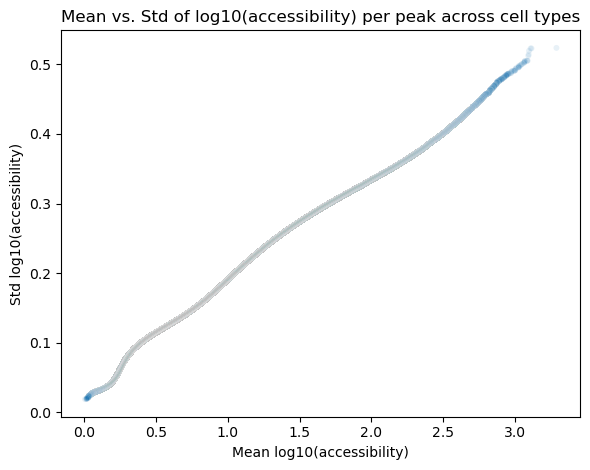

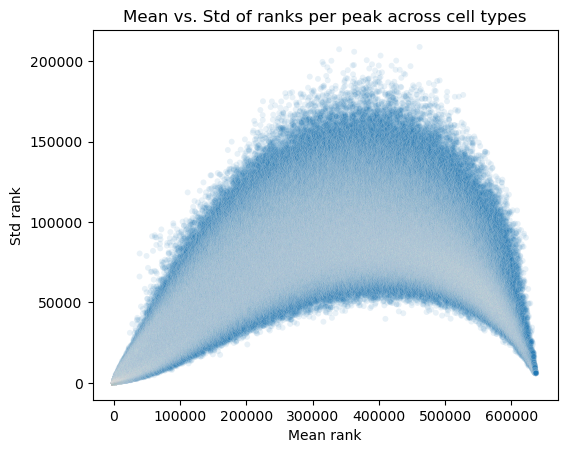

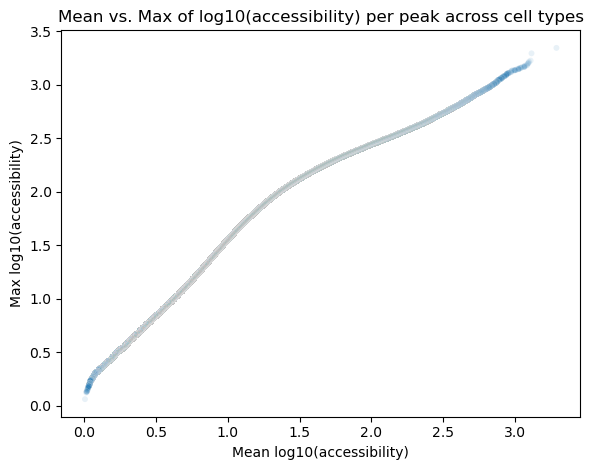

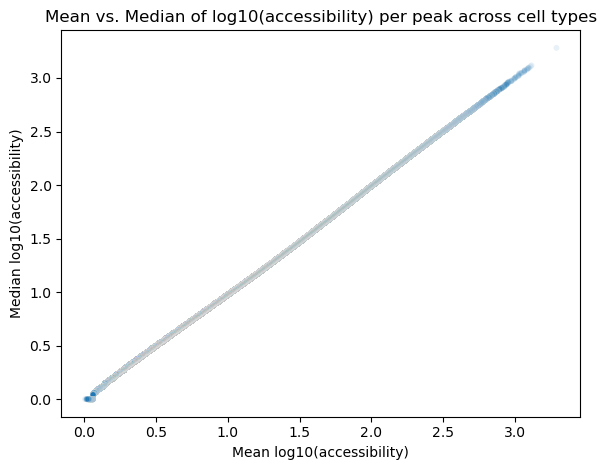

In [42]:
## Plots of statistical value of accessible peaks per cell type 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

P = pb_atac_ct.X #rows = cell types, cols = peaks

if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    std_peak_values = np.asarray(P_log.std(axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    std_peak_values = P_log.std(axis=0) # std across cell types for each peak

peak_std_ct_df = pd.DataFrame({
    "peak": pb_atac_ct.var_names.astype(str),
    "std_accessible_peak": std_peak_values,
}).sort_values("std_accessible_peak", ascending=False).reset_index(drop=True)


plot_ct_df = pd.DataFrame({
    "mean": peak_mean_ct_df["mean_accessible_peak"],
    "std": peak_std_ct_df["std_accessible_peak"],
    "median": peak_median_ct_df["median_accessible_peak"],
    "max": peak_max_ct_df["max_accessible_peak"]
})

plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=plot_ct_df, x="mean", y="std", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean log10(accessibility)")
plt.ylabel("Std log10(accessibility)")
plt.title("Mean vs. Std of log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()



# Rank peaks within each cell type, then summarize ranks across cell types
P = pb_atac_ct.X  # rows = cell types, cols = peaks

# Log-transform first so ranking is based on normalized accessibility values.
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    P_log = P_log.toarray()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)

# Rank peaks within each cell type: rank 1 = highest accessibility in that cell type.
peak_ranks = pd.DataFrame(
    P_log,
    index=pb_atac_ct.obs_names.astype(str),
    columns=pb_atac_ct.var_names.astype(str),
).rank(axis=1, ascending=False, method="average")

# Summarize peak ranks across cell types.
rank_ct_df = pd.DataFrame({
    "peak": peak_ranks.columns,
    "mean_rank": peak_ranks.mean(axis=0).to_numpy(),
    "std_rank": peak_ranks.std(axis=0).to_numpy(),
}).sort_values(
    ["mean_rank", "std_rank"],
    ascending=[True, True],
).reset_index(drop=True)

rank_ct_df["rank"] = np.arange(1, len(rank_ct_df) + 1)

plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=rank_ct_df, x="mean_rank", y="std_rank", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean rank")
plt.ylabel("Std rank")
plt.title("Mean vs. Std of ranks per peak across cell types")

plt.show()

# Optional quick view of the top-ranked peaks.
rank_ct_df.head(10)


plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=plot_ct_df, x="mean", y="max", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean log10(accessibility)")
plt.ylabel("Max log10(accessibility)")
plt.title("Mean vs. Max of log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=plot_ct_df, x="mean", y="median", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean log10(accessibility)")
plt.ylabel("Median log10(accessibility)")
plt.title("Mean vs. Median of log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()  


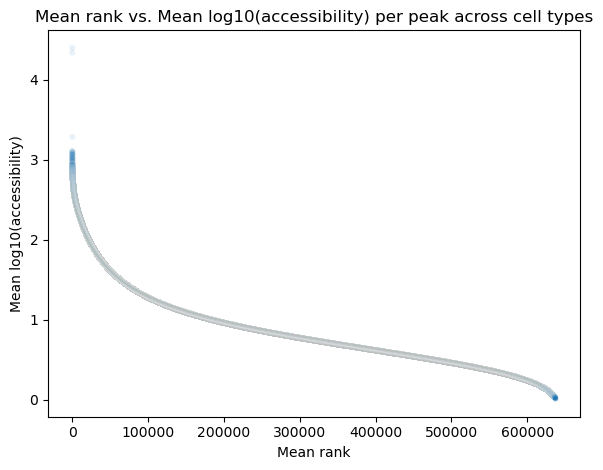

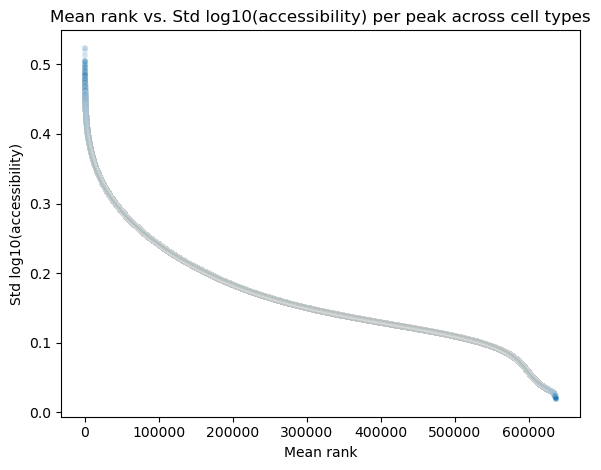

In [27]:
plt.figure(figsize=(6, 4.8))
sns.scatterplot(x= rank_ct_df["mean_rank"], y=plot_ct_df["mean"], alpha=0.1, size=1, legend=False)
plt.xlabel("Mean rank")
plt.ylabel("Mean log10(accessibility)")
plt.title("Mean rank vs. Mean log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.8))
sns.scatterplot(x= rank_ct_df["mean_rank"], y=plot_ct_df["std"], alpha=0.1, size=1, legend=False)
plt.xlabel("Mean rank")
plt.ylabel("Std log10(accessibility)")      
plt.title("Mean rank vs. Std log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()

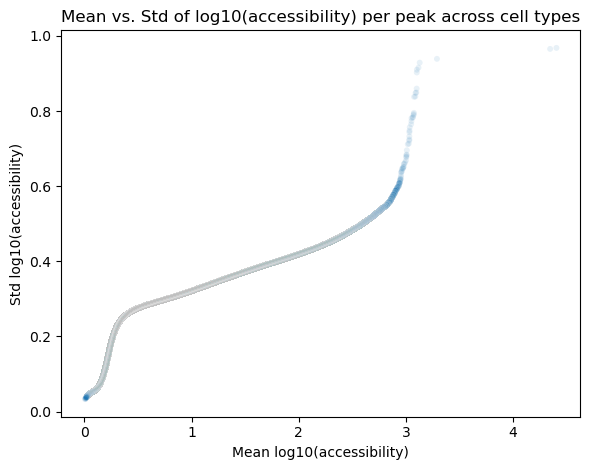

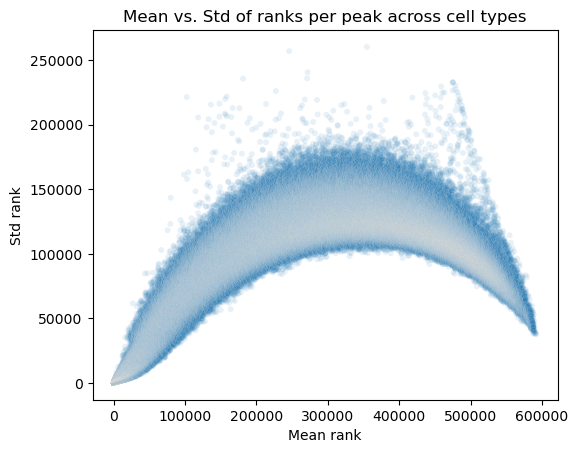

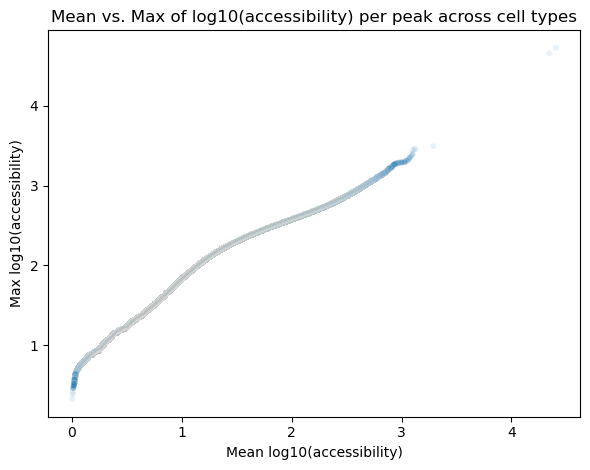

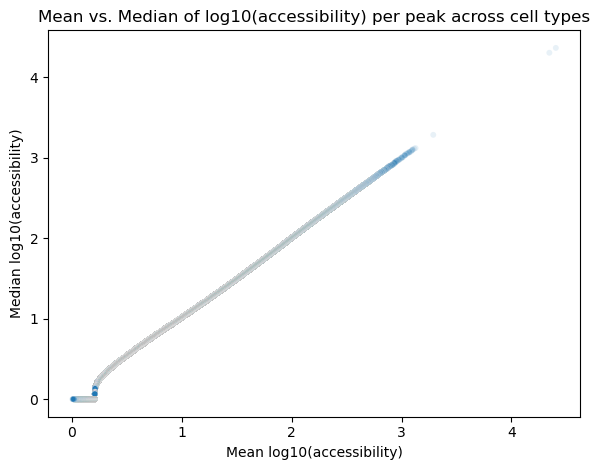

In [30]:
## Plots of statistical value of accessible peaks per cell type and developmental stage
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

P = pb_atac_ct_time.X #rows = cell types, cols = peaks

if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    std_peak_values = np.asarray(P_log.std(axis=0)).ravel()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)
    std_peak_values = P_log.std(axis=0) # std across cell types for each peak

peak_std_ct_time_df = pd.DataFrame({
    "peak": pb_atac_ct_time.var_names.astype(str),
    "std_accessible_peak": std_peak_values,
}).sort_values("std_accessible_peak", ascending=False).reset_index(drop=True)


plot_ct_time_df = pd.DataFrame({
    "mean": peak_mean_ct_time_df["mean_accessible_peak"],
    "std": peak_std_ct_time_df["std_accessible_peak"],
    "median": peak_median_ct_time_df["median_accessible_peak"],
    "max": peak_max_ct_time_df["max_accessible_peak"]
})

plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=plot_ct_time_df, x="mean", y="std", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean log10(accessibility)")
plt.ylabel("Std log10(accessibility)")
plt.title("Mean vs. Std of log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()



# Rank peaks within each cell type, then summarize ranks across cell types
P = pb_atac_ct_time.X  # rows = cell types, cols = peaks

# Log-transform first so ranking is based on normalized accessibility values.
if sparse.issparse(P):
    P_log = P.copy().astype(float)
    P_log.data = np.log10(P_log.data * 10000000 + 1)
    P_log = P_log.toarray()
else:
    P_log = np.log10(np.asarray(P, dtype=float) * 10000000 + 1)

# Rank peaks within each cell type: rank 1 = highest accessibility in that cell type.
peak_ranks = pd.DataFrame(
    P_log,
    index=pb_atac_ct_time.obs_names.astype(str),
    columns=pb_atac_ct_time.var_names.astype(str),
).rank(axis=1, ascending=False, method="average")

# Summarize peak ranks across cell types.
rank_ct_time_df = pd.DataFrame({
    "peak": peak_ranks.columns,
    "mean_rank": peak_ranks.mean(axis=0).to_numpy(),
    "std_rank": peak_ranks.std(axis=0).to_numpy(),
}).sort_values(
    ["mean_rank", "std_rank"],
    ascending=[True, True],
).reset_index(drop=True)

rank_ct_time_df["rank"] = np.arange(1, len(rank_ct_time_df) + 1)

plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=rank_ct_time_df, x="mean_rank", y="std_rank", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean rank")
plt.ylabel("Std rank")
plt.title("Mean vs. Std of ranks per peak across cell types")

plt.show()

# Optional quick view of the top-ranked peaks.
rank_ct_time_df.head(10)


plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=plot_ct_time_df, x="mean", y="max", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean log10(accessibility)")
plt.ylabel("Max log10(accessibility)")
plt.title("Mean vs. Max of log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.8))
sns.scatterplot(data=plot_ct_time_df, x="mean", y="median", alpha=0.1, size=1, legend=False)
plt.xlabel("Mean log10(accessibility)")
plt.ylabel("Median log10(accessibility)")
plt.title("Mean vs. Median of log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()  

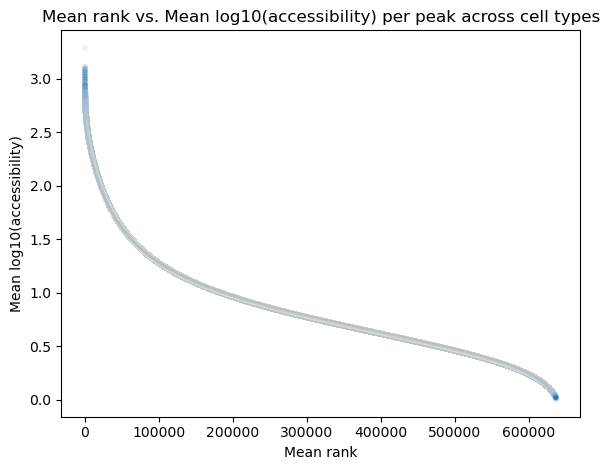

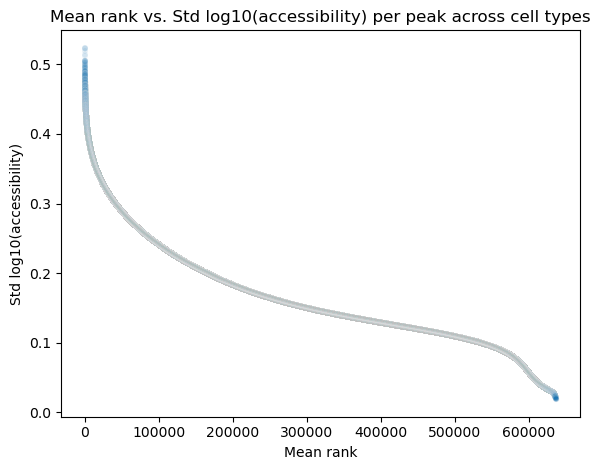

In [43]:
plt.figure(figsize=(6, 4.8))
sns.scatterplot(x= rank_ct_df["mean_rank"], y=plot_ct_df["mean"], alpha=0.1, size=1, legend=False)
plt.xlabel("Mean rank")
plt.ylabel("Mean log10(accessibility)")
plt.title("Mean rank vs. Mean log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.8))
sns.scatterplot(x= rank_ct_df["mean_rank"], y=plot_ct_df["std"], alpha=0.1, size=1, legend=False)
plt.xlabel("Mean rank")
plt.ylabel("Std log10(accessibility)")      
plt.title("Mean rank vs. Std log10(accessibility) per peak across cell types")
plt.tight_layout()
plt.show()

In [45]:
pb_atac_ct.obs.head()

,annotation_ML,nCount_RNA,nCount_ATAC,TSS.enrichment,nucleosome_signal
annotation_ML,,,,,
NMPs,NMPs,4089.427460,32181.299055,4.504159,0.877163
PSM,PSM,4158.554624,31450.270968,4.497317,0.815758
differentiating_neurons,differentiating_neurons,4600.383415,26788.114146,4.456507,0.668380
endocrine_pancreas,endocrine_pancreas,4105.893435,31082.338172,4.539542,0.815210
endoderm,endoderm,4194.597410,32219.110631,4.461370,0.845156
